# EDA: Roboflow `malocclusion-classification/iotn` (Grade-labeled)

Dataset kedua yang berlabel **IOTN Grade langsung** (bukan 30 sub-kode kayak `Malocclusion-Data`) — ditemukan di Roboflow Universe: `universe.roboflow.com/malocclusion-classification/iotn`. Versi yang dipakai: **v14 (`class_filter`)**, dipilih karena paling mentah (626 gambar, tidak ada resize/stretch atau augmentasi yang sudah "dibakar" — beda dari versi-versi lain di project itu yang sudah di-stretch ke 640x640 dan/atau di-augment).

**Kecurigaan yang perlu diverifikasi di notebook ini:** jumlah gambarnya (626) persis sama dengan `Malocclusion-Data-1` yang sudah kita eksplorasi sebelumnya, dan kelasnya sudah langsung `Grade 1`-`Grade 5` (bukan kode IOTN 30-kelas) — kemungkinan besar ini sumber gambar yang sama, cuma sudah di-collapse ke Grade duluan. Kalau benar, ini penting untuk dicek **sebelum** dataset ini digabung ke training manapun — kalau gambarnya tumpang tindih dengan `Malocclusion-Data-1`/`Malocclusion-Data-processed` yang sudah dipakai training/eval sekarang, menggabungkannya bisa menyebabkan data leakage (gambar yang sama muncul di train di satu dataset dan test di dataset lain).

**Tujuan notebook:** load & validasi struktur dataset, cek integritas, distribusi kelas Grade, statistik bbox, visualisasi sampel, dan **cross-check overlap gambar** dengan `Malocclusion-Data-1`.

## 1. Setup

Pakai dataset lokal kalau sudah pernah didownload; kalau belum, download via Roboflow API (API key diminta interaktif, tidak ditulis di notebook).

In [1]:
%pip install -q roboflow


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
from getpass import getpass
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageOps
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [ ]:
LOCAL_DATASET_DIR = Path("../Dataset/IOTN-Grade-1")

if LOCAL_DATASET_DIR.exists():
    ROOT = LOCAL_DATASET_DIR
    print(f"Pakai dataset lokal: {ROOT.resolve()}")
else:
    print("Dataset lokal belum ditemukan, download dari Roboflow...")
    from roboflow import Roboflow

    api_key = getpass("Roboflow API key: ")
    rf = Roboflow(api_key=api_key)
    project = rf.workspace("malocclusion-classification").project("iotn")
    version = project.version(14)  # v14 "class_filter"
    dataset = version.download("coco", location=str(LOCAL_DATASET_DIR))
    ROOT = Path(dataset.location)
    print(f"Dataset terdownload di: {ROOT.resolve()}")

SPLITS = [d.name for d in ROOT.iterdir() if d.is_dir() and (d / "_annotations.coco.json").exists()]
print("Split yang ditemukan:", SPLITS)


## 2. Load anotasi COCO per split

In [4]:
raw = {}
for split in SPLITS:
    with open(ROOT / split / "_annotations.coco.json") as f:
        raw[split] = json.load(f)

categories_raw = pd.DataFrame(raw[SPLITS[0]]["categories"])[["id", "name", "supercategory"]]
categories_raw


,id,name,supercategory
0,0,teeth-t9K9,none
1,1,1,teeth-t9K9
2,2,2,teeth-t9K9
3,3,3,teeth-t9K9
4,4,4,teeth-t9K9
5,5,5,teeth-t9K9


### 2.1 Filter kategori placeholder Roboflow

In [5]:
categories = categories_raw[categories_raw["supercategory"] != "none"].reset_index(drop=True)
cat_id_to_name = dict(zip(categories["id"], categories["name"]))

placeholder = categories_raw[categories_raw["supercategory"] == "none"]
print(f"Kategori placeholder yang difilter: {placeholder['name'].tolist()}")
print(f"Kategori asli: {len(categories)}")
categories


Kategori placeholder yang difilter: ['teeth-t9K9']
Kategori asli: 5


,id,name,supercategory
0,1,1,teeth-t9K9
1,2,2,teeth-t9K9
2,3,3,teeth-t9K9
3,4,4,teeth-t9K9
4,5,5,teeth-t9K9


Ekspektasi: kategori asli langsung `Grade 1`-`Grade 5` (5 kelas), bukan 30 kode sub-IOTN seperti `Malocclusion-Data`. Kalau ternyata bukan, sesuaikan asumsi di bagian bawah notebook ini.

In [6]:
images = {}
annotations = {}

for split in SPLITS:
    imgs = pd.DataFrame(raw[split]["images"])
    imgs["split"] = split
    images[split] = imgs

    anns = pd.DataFrame(raw[split]["annotations"])
    anns["split"] = split
    anns["category_name"] = anns["category_id"].map(cat_id_to_name)
    annotations[split] = anns

images_all = pd.concat(images.values(), ignore_index=True)
annotations_all = pd.concat(annotations.values(), ignore_index=True)

images_all.head()


,id,license,file_name,height,width,date_captured,extra,split
0,0,1,3_jpg.rf.6ea7076a83e8c40d4c8c8e8e1dcb1c10.jpg,640,640,2026-07-24T03:13:08+00:00,{'name': '3.jpg'},train
1,1,1,4_jpg.rf.33d22c425ca70b46d7daf68be88b708a.jpg,640,640,2026-07-24T03:13:08+00:00,"{'user_tags': ['23'], 'name': '4.jpg'}",train
2,2,1,IMG_0306_JPG.rf.a4f0d3b3afb102ef832067ea44d11c...,640,640,2026-07-24T03:13:08+00:00,{'name': 'IMG_0306.JPG'},train
3,3,1,2_jpg.rf.2cecfc724bd0905f522fb3075d338dd5.jpg,640,640,2026-07-24T03:13:08+00:00,{'name': '2.jpg'},train
4,4,1,4_jpg.rf.cdeb1e37c3c49d2fe754af92165884a5.jpg,640,640,2026-07-24T03:13:08+00:00,"{'user_tags': ['27'], 'name': '4.jpg'}",train


In [7]:
annotations_all.head()


,id,image_id,category_id,bbox,iscrowd,area,segmentation,split,category_name
0,1,0,4,"[108.25, 191.5, 117.5, 342]",0,40185.00,[],train,4
1,2,0,4,"[107.25, 193.5, 119.5, 342]",0,40869.00,[],train,4
2,3,0,4,"[106.75, 194.75, 120.5, 338.5]",0,40789.25,[],train,4
3,4,1,1,"[34, 262, 154, 378]",0,58212.00,[],train,1
4,5,1,3,"[320.5, 2, 119, 231]",0,27489.00,[],train,3


## 3. Ringkasan dataset per split

In [8]:
summary_rows = []
for split in SPLITS:
    imgs = images[split]
    anns = annotations[split]
    summary_rows.append({
        "split": split,
        "n_images": len(imgs),
        "n_annotations": len(anns),
        "avg_anns_per_image": len(anns) / len(imgs) if len(imgs) else float("nan"),
    })

summary = pd.DataFrame(summary_rows).set_index("split")
summary


,n_images,n_annotations,avg_anns_per_image
split,,,
train,626,1415,2.260383


In [9]:
print(f"Total gambar : {len(images_all)}")
print(f"Total anotasi: {len(annotations_all)}")


Total gambar : 626
Total anotasi: 1415


## 4. Cek integritas data

In [10]:
print("Jumlah kombinasi (width, height) unik:", images_all[["width", "height"]].drop_duplicates().shape[0], "dari", len(images_all), "gambar")
images_all[["width", "height"]].describe()


Jumlah kombinasi (width, height) unik: 1 dari 626 gambar


,width,height
count,626.0,626.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


In [11]:
missing_files = []
for split in SPLITS:
    imgs = images[split]
    for _, row in imgs.iterrows():
        path = ROOT / split / row["file_name"]
        if not path.exists():
            missing_files.append(str(path))

print(f"File hilang dari {len(images_all)} gambar yang dicek: {len(missing_files)}")
if missing_files:
    print(missing_files[:10])


File hilang dari 626 gambar yang dicek: 0


In [12]:
for split in SPLITS:
    img_ids = set(images[split]["id"])
    ann_img_ids = set(annotations[split]["image_id"])
    orphan_anns = ann_img_ids - img_ids
    images_without_ann = img_ids - ann_img_ids
    print(f"[{split}] anotasi tanpa image terkait: {len(orphan_anns)} | gambar tanpa anotasi: {len(images_without_ann)}")


[train] anotasi tanpa image terkait: 0 | gambar tanpa anotasi: 2


## 5. Distribusi kelas Grade

Ekspektasi: jauh lebih seimbang dibanding 30 kode asli (mengikuti pola yang sudah kita lihat waktu manual collapse 30->5 di `03_yolo_rf_grade.ipynb`: rasio ~3:1, bukan ~91:1).

In [13]:
cat_counts = (
    annotations_all
    .groupby(["split", "category_name"])
    .size()
    .unstack("split")
    .reindex(categories["name"])
    .fillna(0)
    .astype(int)
)
cat_counts["total"] = cat_counts[SPLITS].sum(axis=1)
cat_counts.sort_values("total", ascending=False)


split,train,total
name,,
4,435,435
3,342,342
2,316,316
1,175,175
5,147,147


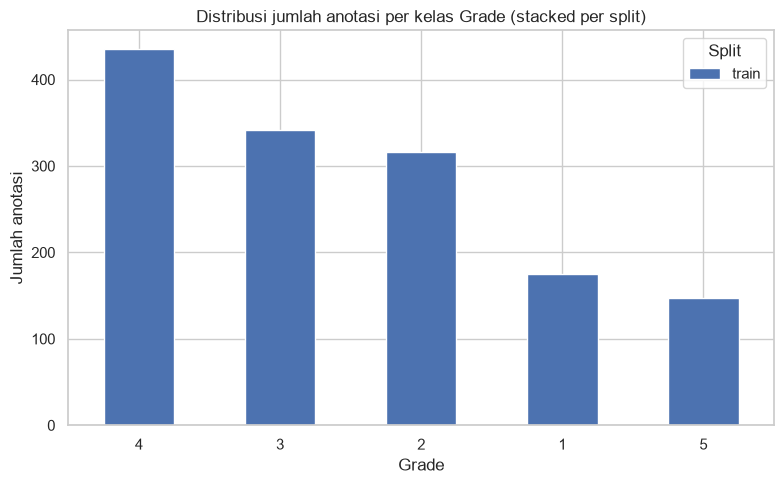

In [14]:
order = cat_counts.sort_values("total", ascending=False).index

fig, ax = plt.subplots(figsize=(8, 5))
cat_counts.loc[order, SPLITS].plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Distribusi jumlah anotasi per kelas Grade (stacked per split)")
ax.set_xlabel("Grade")
ax.set_ylabel("Jumlah anotasi")
ax.legend(title="Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Jumlah anotasi per gambar

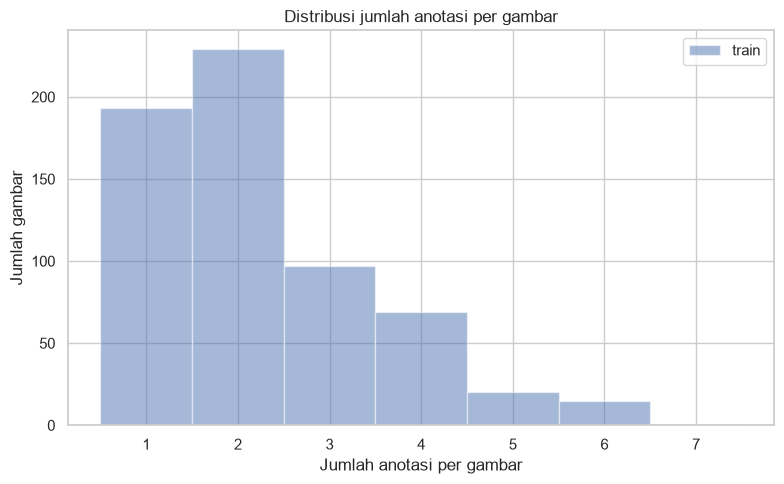

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
train,624.0,2.267628,1.245413,1.0,1.0,2.0,3.0,7.0


In [15]:
anns_per_image = annotations_all.groupby(["split", "image_id"]).size().reset_index(name="n_anns")

fig, ax = plt.subplots(figsize=(8, 5))
for split in SPLITS:
    subset = anns_per_image[anns_per_image["split"] == split]["n_anns"]
    ax.hist(subset, bins=range(1, subset.max() + 2), alpha=0.5, label=split, align="left")
ax.set_title("Distribusi jumlah anotasi per gambar")
ax.set_xlabel("Jumlah anotasi per gambar")
ax.set_ylabel("Jumlah gambar")
plt.legend()
plt.tight_layout()
plt.show()

anns_per_image.groupby("split")["n_anns"].describe()


## 7. Statistik ukuran bounding box

In [16]:
bbox = annotations_all["bbox"].apply(pd.Series)
bbox.columns = ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]
ann_bbox = pd.concat([annotations_all.reset_index(drop=True), bbox], axis=1)

img_dims = images_all.set_index("id")[["width", "height"]]
ann_bbox = ann_bbox.join(img_dims, on="image_id")
ann_bbox["bbox_w_rel"] = ann_bbox["bbox_w"] / ann_bbox["width"]
ann_bbox["bbox_h_rel"] = ann_bbox["bbox_h"] / ann_bbox["height"]
ann_bbox["area_rel"] = ann_bbox["bbox_w_rel"] * ann_bbox["bbox_h_rel"]

ann_bbox.groupby("category_name")[["bbox_w_rel", "bbox_h_rel", "area_rel"]].agg(["count", "mean", "median"])


bbox_w_rel                     bbox_h_rel                      \
                   count      mean    median      count      mean    median   
category_name                                                                 
1                    175  0.281710  0.260937        175  0.552567  0.589844   
2                    316  0.234103  0.187500        316  0.352223  0.337500   
3                    342  0.206556  0.180859        342  0.333235  0.315234   
4                    435  0.228096  0.203906        435  0.360104  0.346875   
5                    147  0.265737  0.246094        147  0.382419  0.371875   

              area_rel                      
                 count      mean    median  
category_name                               
1                  175  0.154712  0.157266  
2                  316  0.090247  0.065311  
3                  342  0.072654  0.058809  
4                  435  0.085215  0.070892  
5                  147  0.102785  0.097378

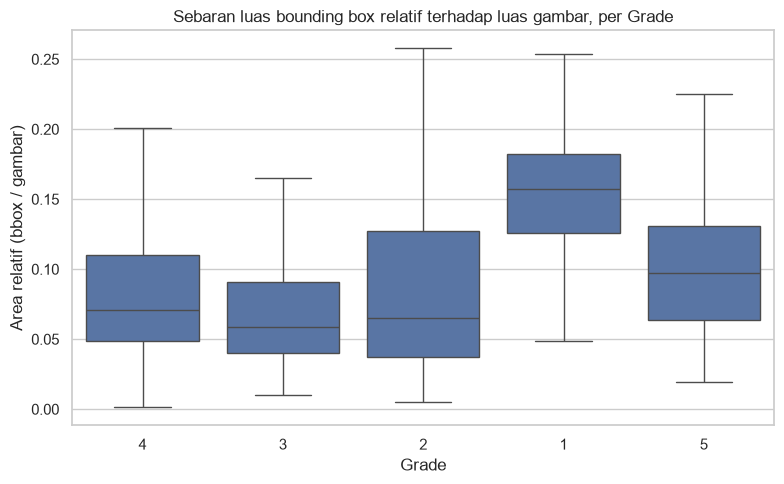

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=ann_bbox, x="category_name", y="area_rel", order=order, ax=ax, showfliers=False)
ax.set_title("Sebaran luas bounding box relatif terhadap luas gambar, per Grade")
ax.set_xlabel("Grade")
ax.set_ylabel("Area relatif (bbox / gambar)")
plt.tight_layout()
plt.show()


## 8. Visualisasi sampel gambar dengan bounding box

In [18]:
def plot_image_with_boxes(split, image_id, ax, max_dim=1000):
    img_row = images[split].set_index("id").loc[image_id]
    img_path = ROOT / split / img_row["file_name"]
    img = Image.open(img_path)
    orig_w = img.width
    img_disp = img.copy()
    img_disp.thumbnail((max_dim, max_dim))
    scale = img_disp.width / orig_w
    ax.imshow(img_disp)

    boxes = annotations[split][annotations[split]["image_id"] == image_id]
    for _, box in boxes.iterrows():
        x, y, w, h = [v * scale for v in box["bbox"]]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 3, 0), box["category_name"], color="white", fontsize=8,
                 bbox=dict(facecolor="red", alpha=0.6, pad=0.5))

    extra = img_row.get("extra")
    title = extra["name"] if isinstance(extra, dict) and "name" in extra else img_row["file_name"]
    ax.set_title(f"{split} | {title}", fontsize=9)
    ax.axis("off")


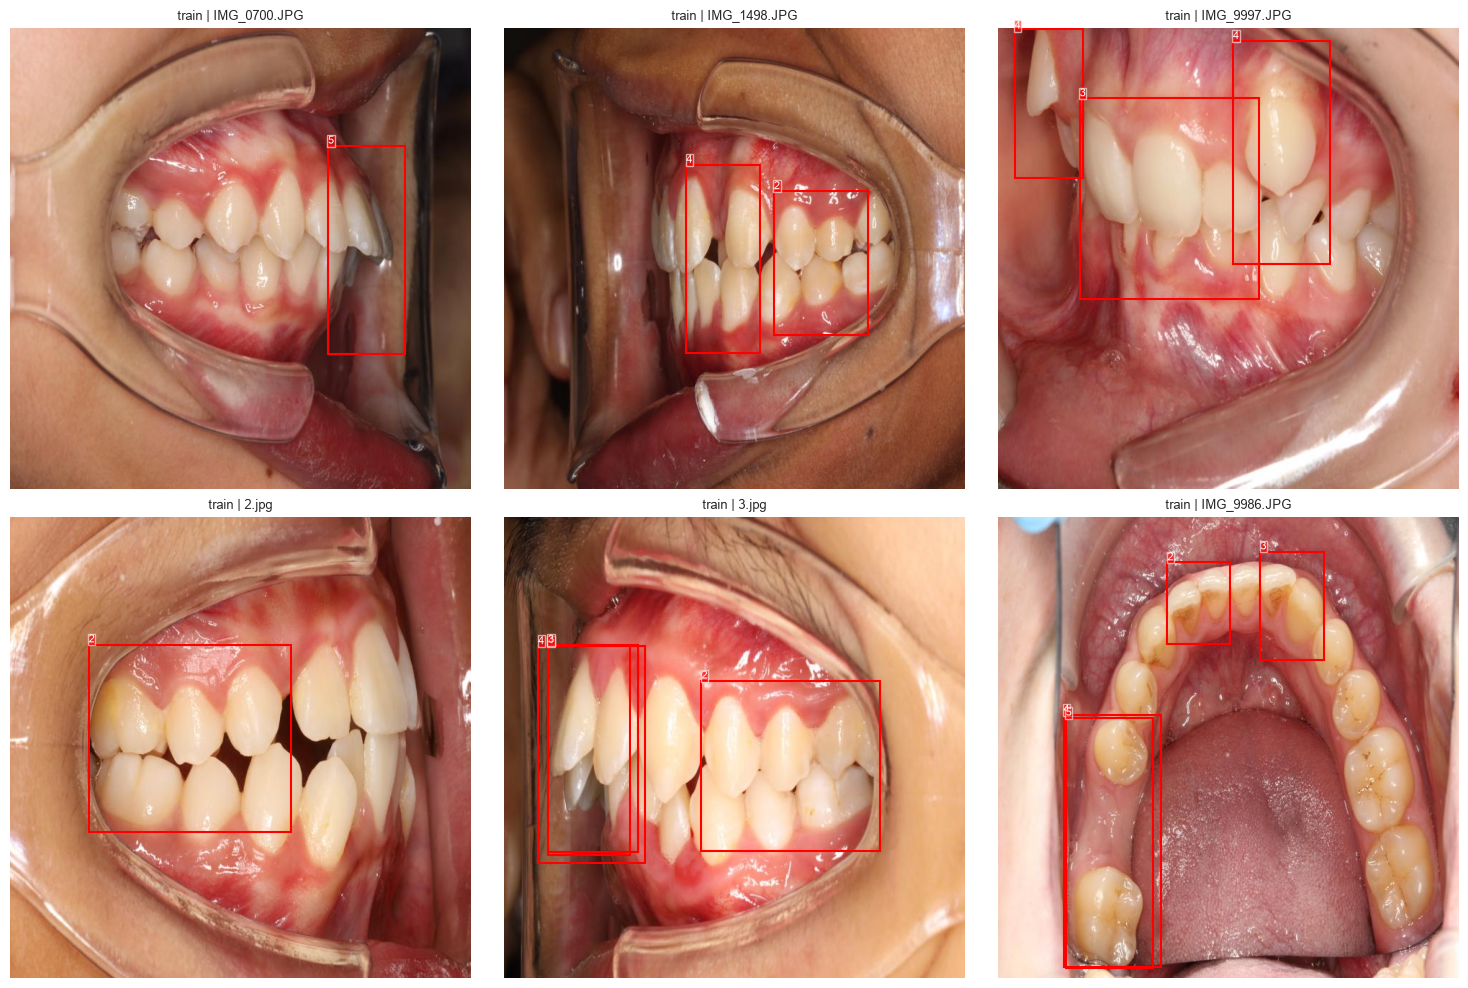

In [19]:
n_samples = min(6, len(images[SPLITS[0]]))
sample_image_ids = images[SPLITS[0]]["id"].sample(n_samples, random_state=1).tolist()

n_cols = 3
n_rows = -(-n_samples // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = np.array(axes).reshape(-1)
for image_id, ax in zip(sample_image_ids, axes):
    plot_image_with_boxes(SPLITS[0], image_id, ax)
for ax in axes[len(sample_image_ids):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 9. Cross-check overlap gambar dengan `Malocclusion-Data-1`

Bandingkan nama file asli (field `extra.name`, nama sebelum di-hash Roboflow) antara dataset ini dengan `Malocclusion-Data-1` yang sudah kita pakai untuk training. Kalau overlap-nya besar (atau 100%), berarti ini sumber foto yang sama dan **tidak boleh digabung mentah-mentah** ke pipeline training yang sudah ada tanpa mengatur ulang split supaya tetap konsisten per-gambar (hindari gambar yang sama muncul di train dataset ini tapi val/test di dataset satunya, atau sebaliknya).

In [20]:
def get_original_names(images_df):
    names = set()
    for extra in images_df["extra"]:
        if isinstance(extra, dict) and "name" in extra:
            names.add(extra["name"])
    return names

iotn_names = get_original_names(images_all)
print(f"Jumlah nama file asli unik di dataset ini: {len(iotn_names)}")

OLD_DATASET_ROOT = Path("../Dataset/Malocclusion-Data-1")
old_names = set()
if OLD_DATASET_ROOT.exists():
    for split in ["train", "valid"]:
        split_dir = OLD_DATASET_ROOT / split
        ann_file = split_dir / "_annotations.coco.json"
        if ann_file.exists():
            with open(ann_file) as f:
                old_raw = json.load(f)
            old_images = pd.DataFrame(old_raw["images"])
            old_names |= get_original_names(old_images)
    print(f"Jumlah nama file asli unik di Malocclusion-Data-1: {len(old_names)}")

    overlap = iotn_names & old_names
    print(f"Overlap nama file: {len(overlap)} dari {len(iotn_names)} ({len(overlap) / len(iotn_names) * 100:.1f}%)")
else:
    print(f"{OLD_DATASET_ROOT} tidak ditemukan lokal -- lewati cross-check (jalankan dari folder notebooks/ dengan Dataset/Malocclusion-Data-1 sudah ada).")


Jumlah nama file asli unik di dataset ini: 393
Jumlah nama file asli unik di Malocclusion-Data-1: 393
Overlap nama file: 393 dari 393 (100.0%)


## 10. Catatan / temuan awal

**Dataset ini terkonfirmasi 100% sama sumbernya dengan `Malocclusion-Data-1` — sudah diverifikasi di level pixel, bukan cuma nama file**
- 393 nama file asli unik di kedua dataset, overlap 100%.
- Sampel 8 nama file `IMG_XXXX.JPG` yang overlap dicek pakai perceptual hash (bukan cuma cocok nama) — hasilnya hamming distance 0-2 (praktis identik, cuma beda resolusi hasil resize Roboflow yang beda-beda per versi). Ini konfirmasi kuat secara visual, bukan cuma tebakan dari metadata.
- Distribusi kelas Grade nyaris identik sama hasil collapse manual kita di `03_yolo_rf_grade.ipynb`: Grade 4=435 (persis sama), Grade 2=316 (persis sama), Grade 5=147 (persis sama), Grade 1=175 (kita: 176), Grade 3=342 (kita: 343).
- **Implikasi:** dataset ini TIDAK bisa dipakai sebagai data tambahan — isinya duplikat dari yang sudah kita pakai.

**Struktur beda dari ekspektasi**
- Cuma ada 1 split: `train` (626 gambar) — tidak ada train/valid/test terpisah di export v14 ini.
- Gambar sudah diresize ke 640×640 seragam, meski v14 ("class_filter") diasumsikan paling mentah — asumsi awal keliru, kemungkinan semua versi di project ini tetap melalui resize.
- Kategori aslinya bernama `"1"`-`"5"` (bukan `"Grade 1"`-`"Grade 5"` seperti tampilan UI Roboflow).

**KOREKSI PENTING — klaim "data leakage di `Malocclusion-Data-processed`" yang sempat ditulis di sini SALAH, sudah dibantah verifikasi pixel**

Investigasi awal (cuma berdasarkan kecocokan nama file `extra.name`) sempat menyimpulkan `Malocclusion-Data-1` punya 52 foto "duplikat" yang sebagian splitnya kecampur di `Malocclusion-Data-processed`. **Setelah dicek ulang pakai perceptual hash ke isi gambar aslinya** (bukan cuma nama), kesimpulan itu terbukti salah:

- 39 dari 52 grup nama duplikat berpola `IMG_XXXX.JPG` — **semua 39 grup itu ternyata foto yang BERBEDA** (hamming distance antar pasangan 18-44, jauh dari identik; resolusi juga beda-beda). Ini foto pasien berbeda yang kebetulan nama filenya sama — wajar terjadi karena `IMG_XXXX.JPG` itu nama default kamera yang counter-nya bisa reset/tabrakan antar sesi motret berbeda.
- 13 grup lainnya nama generik super pendek (`3.jpg`, `4.jpg`, dst, sampai puluhan entri per nama) — dicek sampel beberapa juga terbukti foto berbeda-beda (resolusi & hash beda semua).
- **Kesimpulan: tidak ada bukti duplikasi foto asli di dalam `Malocclusion-Data-1`.** Nama file yang sama ternyata bukan indikator isi yang sama untuk dataset ini — pelajaran metodologis: jangan pakai kecocokan filename sebagai proxy identitas gambar tanpa verifikasi pixel, terutama kalau nama filenya generik/default kamera.
- **Jadi: tidak ada indikasi data leakage di `Malocclusion-Data-processed`.** Semua angka mAP yang sudah dilaporkan di `03_yolo_rf_grade.ipynb` (baseline, grade-only, tuned, transfer learning) tetap valid dari sisi ini — tidak perlu di-rerun ulang karena alasan leakage.

**Rekomendasi tindak lanjut**
- Dataset `IOTN Grade` ini disimpan sebagai referensi/dokumentasi saja, tidak dipakai untuk training (murni duplikat sumber yang sama).
- Rencana k-fold cross-validation yang sempat didiskusikan tetap relevan untuk dapat estimasi performa yang lebih stabil dari data terbatas — tapi bukan lagi didorong oleh alasan "fix leakage" (karena leakage-nya tidak terbukti ada), murni buat efisiensi pemakaian data yang sedikit.
